<a href="https://colab.research.google.com/github/sebenemaryamashebir-cmd/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

**Part 1.1 — A single neuron is just a line**

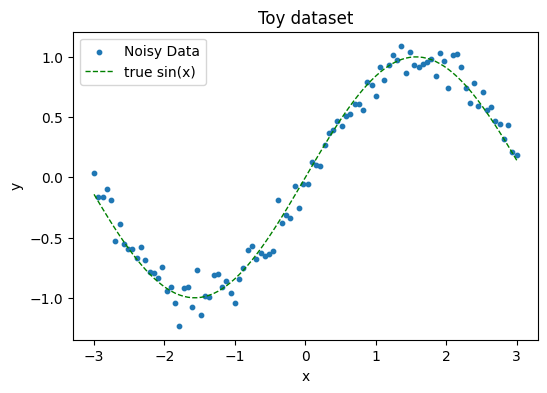

In [2]:
# Generating the toy data
np.random.seed(0)
x= np.linspace(-3,3,100)
y= np.sin(x)+ np.random.normal(loc=0.0, scale =0.1, size= x.shape)

# Plotting the data
plt.figure(figsize=(6,4))
plt.scatter(x,y, s=10, label = "Noisy Data")
plt.plot(x, np.sin(x), 'g--', linewidth=1, label ="true sin(x)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy dataset")
plt.show()

Final: w =0.3318, b = 0.0060, final loss = 0.0000


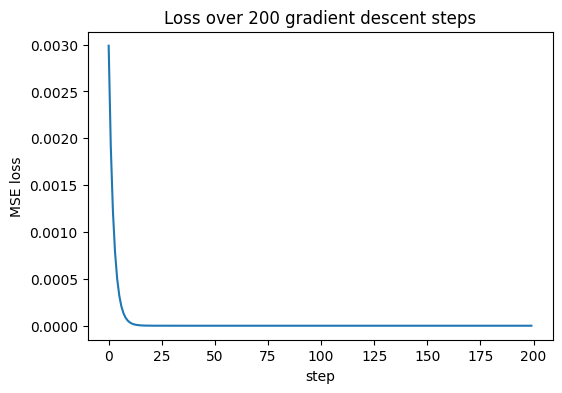

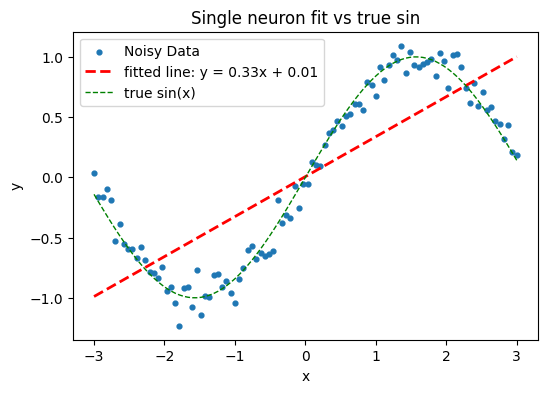

In [3]:
# Initialize w and b
w= np.random.rand() *0.1
b= np.random.rand() * 0.1 # making the initial values as small as possible

# Implement One gradient-descent

lr= 0.1 # The learning rate
n_step = 200
losses =[]
for step in range(n_step):
  y_hat = w * x + b
  loss = np.mean(y_hat -y) **2     # Mean Squared Error (MSE)
  losses.append(loss)
  dw= np.mean(2 * (y_hat - y) * x)            # dLoss/dw
  db= np.mean(2 * (y_hat - y))                # dLoss/db
  w-= lr * dw
  b-= lr * db
print (f"Final: w ={w:.4f}, b = {b:.4f}, final loss = {losses[-1]:.4f}")

# Plot loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.title("Loss over 200 gradient descent steps")
plt.show()

# Plot data with the fitted line
plt.figure(figsize=(6,4))
plt.scatter(x,y, s=12, label = "Noisy Data")
plt.plot(x,w * x + b, 'r--', linewidth=2, label =f"fitted line: y = {w:.2f}x + {b:.2f}")
plt.plot(x, np.sin(x), 'g--', linewidth=1, label ="true sin(x)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Single neuron fit vs true sin")
plt.show()


1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?



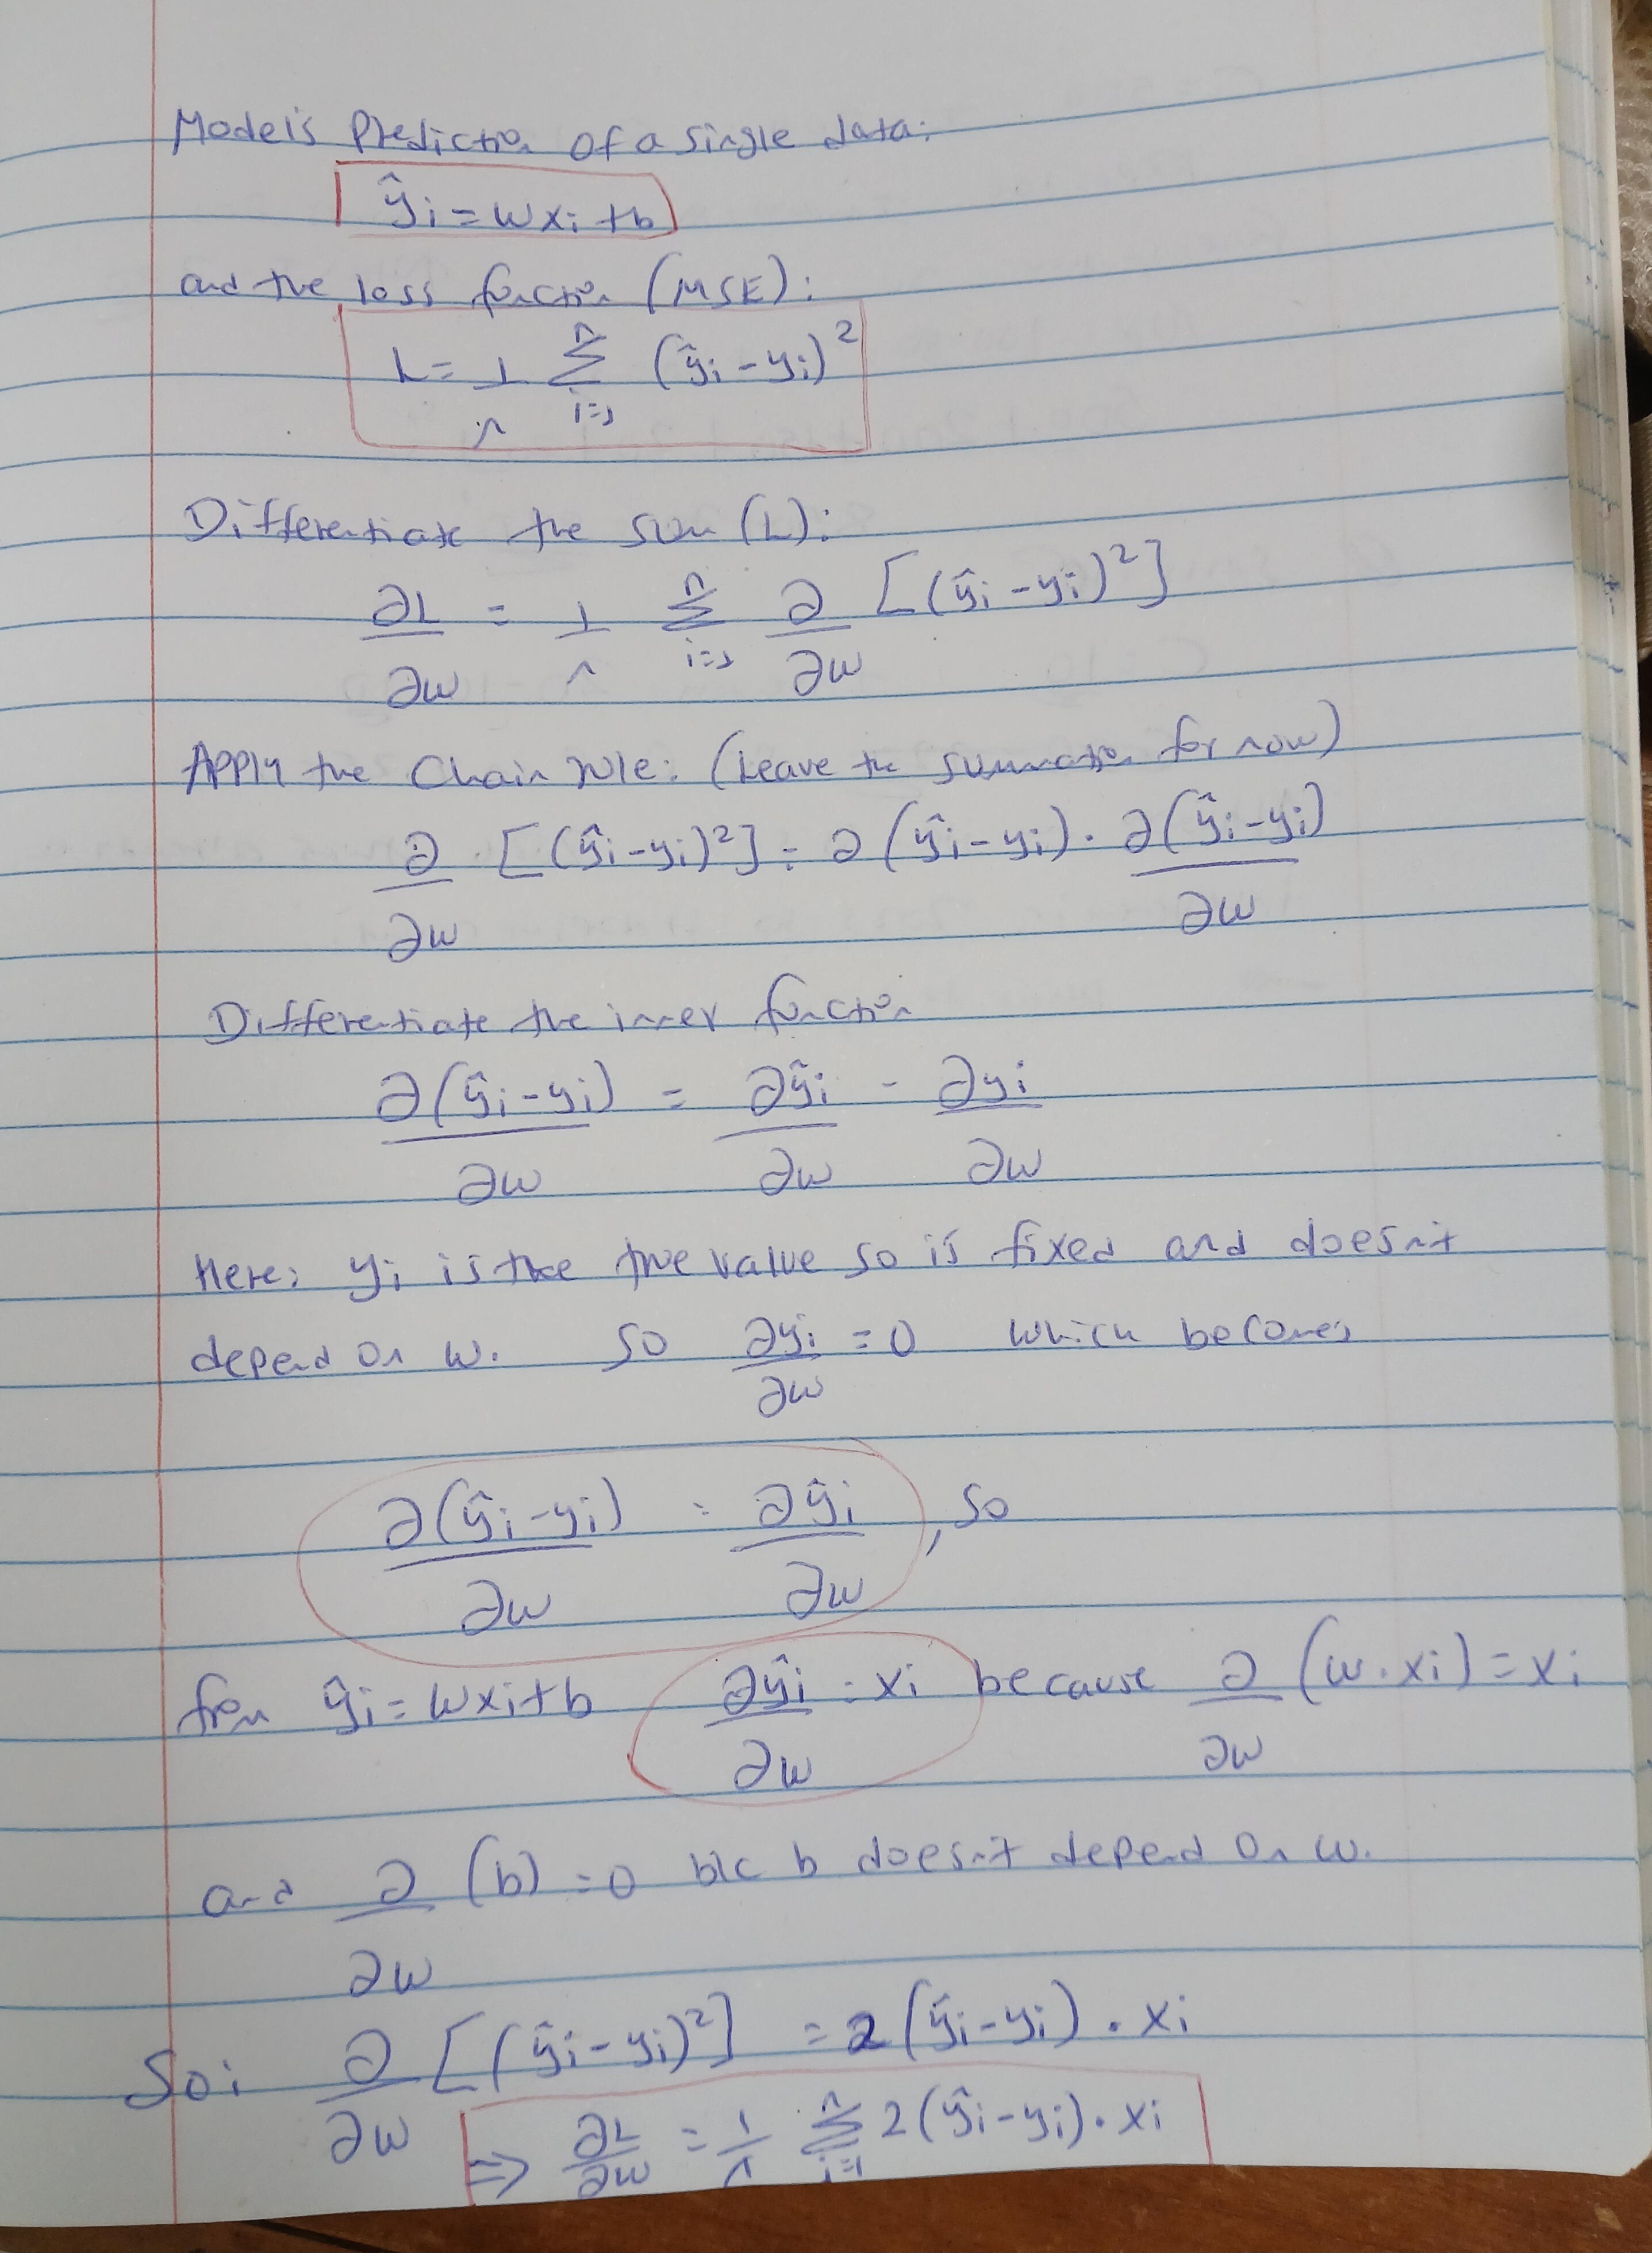


- Yes, it matches the code. The code is dw = np.mean(2 * (y_hat - y) * x) and The np.mean(...) part computes the summation ( 1/n...). The 2 * (y_hat - y) * x, is  2(y ̂_i-y_i)⋅x_i which is computed for every data point, then averaged.

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?
- This is underfitting because the model lacks the capacity to represent the true relationship. The single neuron computes only y ̂=wx+b, which is a straight line, however, the sine wave is curved, and no straight line can fit it perfectly.
- So, the gradient descent tries to find the best possible straight line to fit the model. And once it finds he best line, the loss stops improving. That’s why the loss is not making any change even though the fit is bad.
- To learn the curves like the sine wave, we need to introduce a nonlinear activation model function, so that no feature is left unlearned.



**Part 1.2 — Hidden layers and activations: why depth helps**

Final loss: 0.0125


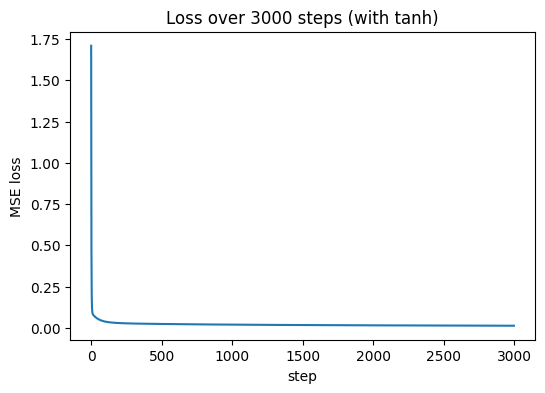

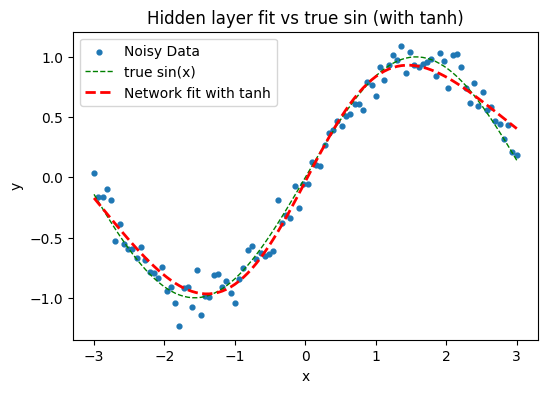

Final loss (not tanh, linear): 0.17912


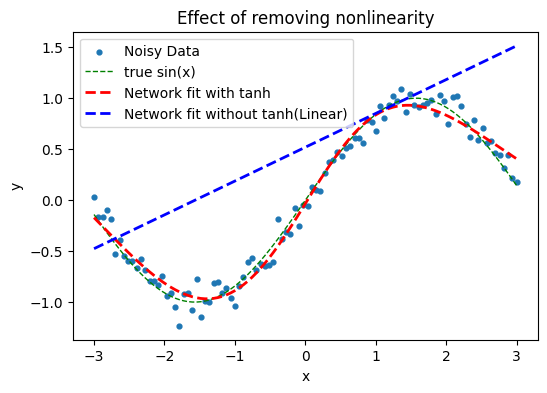

In [4]:
# Changing 1D to 2D
x_col = x.reshape(-1,1)
y_col = y.reshape(-1,1)
# Initialize parameters
np.random.seed(1)
W1= np.random.randn(1,8) *0.5 # Multiply by 0.5 to make the weight smaller
b1=  np.random.randn(8) *0.5 # bias for every hidden node
W2=  np.random.randn(8,1) *0.5
b2=  np.random.randn(1) *0.5 # bias for output node

# Learning rate
lr= 0.05
n_steps = 3000
losses =[]
def forward (x_col, W1,b1,W2,b2):
  z1= x_col @ W1 + b1 # pre-activation
  h= np.tanh(z1)        # activation
  y_hat= h @ W2 + b2     # output, shape (100, 1)
  return z1, h, y_hat

for step in range(n_steps):
  # Foward pass
  z1, h, y_hat = forward(x_col, W1, b1, W2, b2)
  loss= np.mean((y_hat - y_col) ** 2)
  losses.append(loss)

  # Backward pass
  d_yhat = 2 * (y_hat - y_col) / len(y_col)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
  dW1 = x_col.T @ dz1
  db1 = dz1.sum(axis=0)

  # Update all parameters (gradient descent)
  W1-= lr * dW1 # this moves the weight opposite to the gradient(-)
  b1-= lr * db1
  W2-= lr * dW2
  b2-= lr * db2
print(f"Final loss: {losses[-1]:.4f}")


# Plot the loss curve and final fit over the data
# Plot of loss
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("MSE loss")
plt.title("Loss over 3000 steps (with tanh)")
plt.show()

# Plot of final fit (prediction)
z, h, y_hat_final = forward(x_col, W1, b1, W2, b2)
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=12, label="Noisy Data")
plt.plot(x, np.sin(x), 'g--', linewidth=1, label="true sin(x)")
plt.plot(x,y_hat_final, 'r--', linewidth=2, label="Network fit with tanh")
plt.legend()
plt.title ("Hidden layer fit vs true sin (with tanh)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Train again (Re-run) with tanh removed: removing the nonlinearity (h=z1)
np.random.seed(1)
W1_lin= np.random.randn(1,8) *0.5
b1_lin= np.random.randn(8) *0.5
W2_lin= np.random.randn(8,1) *0.5
b2_lin= np.random.randn(1) *0.5

losses_linear =[]

for step in range(n_steps):
  # Forward pass
  z1= x_col @ W1_lin + b1
  h= z1 # no activation function
  y_hat= h @ W2_lin + b2
  loss = np.mean((y_hat - y_col)**2)
  losses_linear.append(loss)

 # Back propagation
  d_yhat = 2 * (y_hat - y_col) / len(y_col)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2_lin.T
  dz1 = dh * 1   # there is no transformation between z1 and h, so the derivative is 1
  dW1 = x_col.T @ dz1
  db1 = dz1.sum(axis=0)

# Update parameters
  W1_lin -= lr * dW1
  b1_lin -= lr * db1
  W2_lin -= lr * dW2
  b2_lin -= lr * db2

print(f"Final loss (not tanh, linear): {losses_linear[-1]:.5f}")

# Comparing both models
z1_lin = x_col @ W1_lin + b1_lin
y_hat_lin = z1_lin @ W2_lin + b2_lin

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=12, label="Noisy Data")
plt.plot(x, np.sin(x), 'g--', linewidth=1, label="true sin(x)")
plt.plot(x,y_hat_final, 'r--', linewidth=2, label="Network fit with tanh")
plt.plot(x,y_hat_lin, 'b--', linewidth=2, label="Network fit without tanh(Linear)")
plt.legend()
plt.title ("Effect of removing nonlinearity")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.
- With tanh removed,

h= z1= xW1+b1,

then y_hat = hW2+b2

when substituting h value in y_hat:

y_hat = (xW1+b1) W2 +b2 = xW1W2 +b1W2+b2

then to simplify let w’= W1W2, and b’ = b1W2+b2

so, y_hat = xW’+ b’
- This gives the same single node as Part 1.1 that’s y_hat = wx+b which is one linear function of x.
- This is because with tanh removed the model is changed from nonlinear to linear layer. Therefore, having a stack of linear layers without nonlinear activation does not increase the model’s complex power. It only learns linear relationships and cannot model the nonlinear sine curve.
2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)
- Each hidden layer learns a different nonlinear features of the input. So, the hidden layers acted as a feature detector capturing different parts of the curve while the output layer combines them to produce
the final prediction.
3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?
- Backpropagation is the process if tracing back the prediction error backward through the network to calculate how each weight should be adjusted to reduce the loss or error.

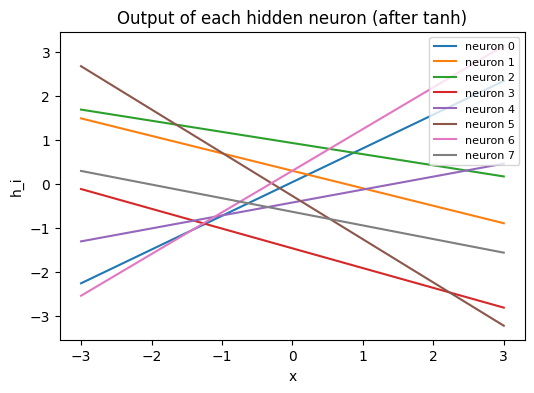

In [5]:
# answer for question 2 on what each neuron learns
plt.figure(figsize=(6, 4))
for i in range(8):
    plt.plot(x, h[:, i], label=f"neuron {i}")
plt.legend(fontsize=8)
plt.xlabel("x"); plt.ylabel("h_i")
plt.title("Output of each hidden neuron (after tanh)")
plt.show()
# This shows a smooth s-shaped curve because tanh values are between -1 and 1.

**Part 1.3 — The learning rate: too cold, too hot, just right**

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1324/2724790399.py:15: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_1324/2724790399.py:22: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/tmp/ipykernel_1324/2724790399.py:23: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


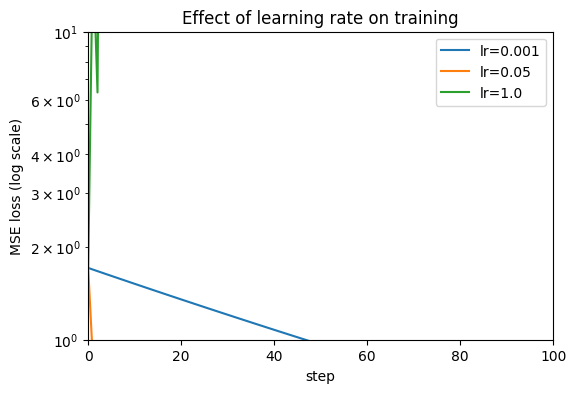

In [6]:
# wrapping the training loop in the function
def train_toy (lr, steps =3000):
  np.random.seed(1)
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.random.randn(8) * 0.5
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses =[]
  for step in range(steps):
    # forward pass
    z1 = x_col @ W1 + b1
    h  = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

    # backward pass
    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    # update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

  return losses
# With three learning rates
learning_rates = [0.001,0.05,1.0]
results ={}

for lr in learning_rates:
  results[lr]= train_toy(lr, steps =3000)

# plot the three loss curves
plt.figure(figsize=(6,4))

for lr, losses in results.items():
  plt.plot(losses, label =f"lr={lr}")

plt.yscale("log")
plt.xlim(0,100) # zooming into the first 100 steps to see the lines clearly
plt.xlabel("step")
plt.ylabel("MSE loss (log scale)")
plt.title("Effect of learning rate on training")
plt.legend()
plt.show()

1.	Describe what each of the three curves shows.
-	Blue: lr = 0.001 – Too cold: The loss decreases slowly and steadily. The model is learning, but each update is very small, so it takes a long time to improve. Training is stable, but it learns too slowly and is time consuming.
-	Orange: lr = 0.05 – Just right: The loss drops quickly in the first few steps and then levels off. The model learns efficiently and reaches a good solution without becoming unstable. This is the best learning rate among the three.
-	Green: lr = 1.0 – Too hot: The loss jumps up and down instead of decreasing smoothly because the updates are too large. The model overshoots the best solution, causing the loss to grow rapidly until training becomes unstable and eventually fails.

2.	Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?
-	A too-large learning rate makes the model take steps that are too big, causing it to overshoot the minimum instead of moving toward it. As a result, the loss oscillates or keeps increasing instead of decreasing. Eventually, the values become extremely large, causing overflow and errors. In other words, the model is not learning faster rather it is skipping over the correct solution.

# Section 2 — A Real Feedforward Network in PyTorch

**Part 2.1 — Preprocess and split (recycled from Lab 2)**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
RANDOM_STATE = 42

# Loading the obesity dataset
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
ob = pd.read_csv (OBESITY_URL)

# Encode binary yes/no columns
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    ob[col] = ob[col].map({"yes": 1, "no": 0})

# Encode gender
ob["Gender"]= ob["Gender"].map({"Female": 0, "Male": 1})

# Encode the remaining nominal categories  (one-hot encoding)
nominal_cols = ["CAEC", "CALC", "MTRANS"]
ob = pd.get_dummies (ob, columns=nominal_cols, drop_first = False)

# Encode the target NObeyesdad into integers 0...6
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(ob["NObeyesdad"])
X = ob.drop(columns=["NObeyesdad"])

# changing from get_dummies to int
X= X.astype(int)

# Stratified train / validation / test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)


# Fit a StandardScaler on the TRAINING set only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# wrap in DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Validation and test sets have shuffle=False because no learning happens here.

print(f"Train: {X_train_t.shape}, Val: {X_val_t.shape}, Test: {X_test_t.shape}")
print(f"Number of classes: {len(target_encoder.classes_)}")



Train: torch.Size([1266, 26]), Val: torch.Size([422, 26]), Test: torch.Size([423, 26])
Number of classes: 7


1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?
- CrossEntropyLoss expects integer class labels because it directly selects the correct class from the model's output instead of comparing every class in a one-hot vector. This is more memory-efficient and faster, since it combines log_softmax and the loss calculation into one operation.
2. Why do neural networks care so much about feature scaling, when a random forest didn't?
- Neural networks use gradients to update weights. If features have very different scales, large-valued features produce much larger gradient updates, making training unstable or slow. Scaling keeps updates balanced. Random forests do not use gradients because they split data using thresholds, so feature scaling has little effect on their performance.
3. What does shuffle=True on the training DataLoader do, and why does it help?
- shuffle=True randomly changes the order of the training data at the start of each epoch. This prevents the model from learning patterns based on the data order and helps it generalize better by exposing it to different mini-batches during training.

**Part 2.2 — Design the network**

In [8]:
# Define the FeedForwardNet class
class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes =(64,32), n_classes=7):
    super().__init__()
    layers=[]
    prev_size = input_dim

    # creating hidden layers

    for hidden_size in hidden_sizes:
      layers.append(nn.Linear(prev_size, hidden_size))
      layers.append(nn.ReLU())
      prev_size= hidden_size # updating the previous size


    # output layer producing 7 raw logits (outputs)
    layers.append(nn.Linear(prev_size, n_classes))
    self.net= nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)

# Instantiate, move to DEVICE, print the model
input_dim = X_train_t.shape[1]
model = FeedForwardNet(input_dim, hidden_sizes=(64,32), n_classes=7)
model = model.to(DEVICE)

print(model)

# count trainable parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
    )
print(f"\nTotal trainable parameters: {total_params}")

# verify the count for the first layer by hand
first_layer_params = input_dim * 64 + 64
print(f"First layer hand: {input_dim} * 64 + 64 = {first_layer_params}")


FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

Total trainable parameters: 4039
First layer hand: 26 * 64 + 64 = 1728


1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.
- Each Linear layer has:
Parameters = (inputs × outputs) + outputs

Input → Hidden 1 (64):

         "input_dim"×64+64

Hidden 1 → Hidden 2 (32):

          64×32+32=2080

Hidden 2 → Output (7):

           32×7+7=231

Add the parameters from all three layers to get the total. This should exactly match the value printed by:

sum(p.numel() for p in model.parameters() if p.requires_grad)

because PyTorch counts every weight and bias in the network.

2. Why ReLU here instead of the tanh used in Section 1? Name one advantage.
- ReLU is used because it helps the network learn faster and reduces the vanishing gradient problem. Unlike tanh, ReLU does not ignore large positive values, so gradients stay larger during backpropagation, making training easier, especially in deeper networks.

3. What would the network compute if you removed the ReLUs?
- Without the ReLU activation functions, all the layers become linear. Stacking several linear layers is equivalent to one linear layer, so the network would only learn a linear relationship between the input and the output. This greatly reduces its ability to learn complex patterns, just as you showed in Part 1.2 with the sine wave example.

**Part 2.3 — The training loop**

<>:69: SyntaxWarning: invalid escape sequence '\B'
<>:69: SyntaxWarning: invalid escape sequence '\B'
/tmp/ipykernel_1324/462411174.py:69: SyntaxWarning: invalid escape sequence '\B'
  print(f"\Best validation accuracy: {best_val_acc:.4f}")


Epoch  1/50 | Train_loss =1.7103 train_acc=0.5000 | Val_loss =1.7077 val_acc=0.5190
Epoch  2/50 | Train_loss =1.3906 train_acc=0.6111 | Val_loss =1.3284 val_acc=0.5261
Epoch  3/50 | Train_loss =0.7815 train_acc=0.7222 | Val_loss =1.0475 val_acc=0.6066
Epoch  4/50 | Train_loss =0.8721 train_acc=0.7222 | Val_loss =0.9060 val_acc=0.6588
Epoch  5/50 | Train_loss =0.7779 train_acc=0.6111 | Val_loss =0.8082 val_acc=0.7156
Epoch  6/50 | Train_loss =0.7995 train_acc=0.6667 | Val_loss =0.7384 val_acc=0.7607
Epoch  7/50 | Train_loss =0.4570 train_acc=0.8333 | Val_loss =0.6932 val_acc=0.7630
Epoch  8/50 | Train_loss =0.5354 train_acc=0.8333 | Val_loss =0.6527 val_acc=0.7844
Epoch  9/50 | Train_loss =0.4136 train_acc=0.8333 | Val_loss =0.6250 val_acc=0.7986
Epoch 10/50 | Train_loss =0.2773 train_acc=0.9444 | Val_loss =0.6008 val_acc=0.8057
Epoch 11/50 | Train_loss =0.4226 train_acc=0.8889 | Val_loss =0.5865 val_acc=0.7986
Epoch 12/50 | Train_loss =0.2053 train_acc=1.0000 | Val_loss =0.5802 val_acc

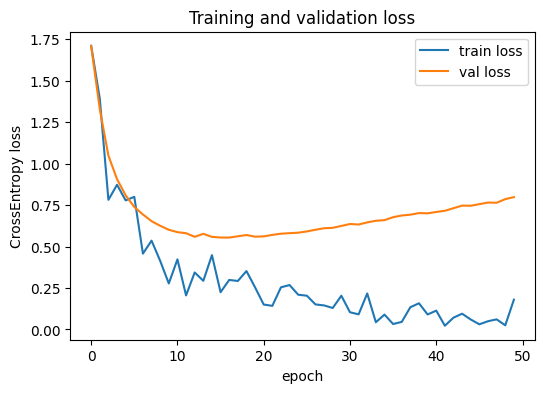

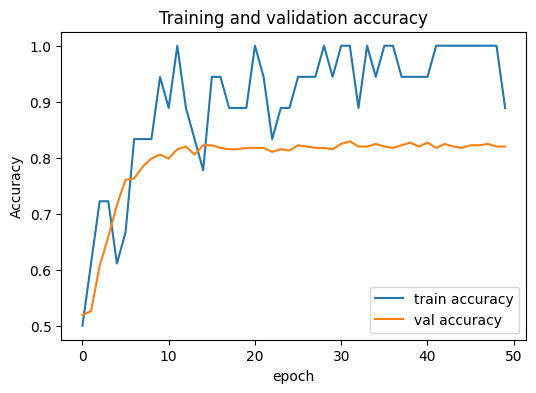

In [9]:
# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# Adam handles very difficult gradient scales which is better than SGD with fixed learning rate

n_epochs = 50
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

best_val_acc = 0.0

def evaluate(loader, model, criterion):
  model.eval()
  total_loss, correct, total=0.0, 0, 0
  with torch.no_grad():
    for xb, yb in loader: # loop through validation batches
      xb, yb = xb.to(DEVICE), yb.to(DEVICE)
      logits = model(xb)
      loss= criterion(logits, yb)
      total_loss += loss. item() * xb.size(0)
      preds = logits.argmax(dim=1)
      correct += (preds == yb).sum().item()
      total += xb.size(0)
  return total_loss / total, correct / total # average loss

for epoch in range(n_epochs):
  # training
  model.train()
  running_loss, running_correct, running_total = 0.0, 0, 0

  for xb, yb in train_loader:
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    optimizer.zero_grad() # remove old gradients
    logits = model(xb) # prediction
    loss = criterion(logits, yb)
    loss.backward() # compute all gradients
    optimizer.step() # update weight and biases


  running_loss += loss.item() * xb.size(0)
  preds = logits.argmax(dim=1)
  running_correct += (preds == yb).sum().item() # count correct predictions
  running_total += xb.size(0)

  train_loss = running_loss / running_total
  train_acc = running_correct / running_total

  # validation

  val_loss, val_acc = evaluate (val_loader, model, criterion)

  # save results
  history["train_loss"].append(train_loss)
  history["val_loss"].append(val_loss)
  history["train_acc"].append(train_acc)
  history["val_acc"].append(val_acc)

  print(f"Epoch {epoch+1:2d}/{n_epochs} | "
  f"Train_loss ={train_loss:.4f} train_acc={train_acc:.4f} | "
  f"Val_loss ={val_loss:.4f} val_acc={val_acc:.4f}")

# save the best model
if val_acc > best_val_acc:
  best_val_acc = val_acc
  torch.save(model.state_dict(), "best_model.pt")

print(f"\Best validation accuracy: {best_val_acc:.4f}")


# plot loss curves

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("CrossEntropy loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()


# plot accuracy curves
plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()


1.	Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?

- PyTorch: logits = model(xb)
- NumPy Equivalent: Forward pass (z1 = x @ W1 + b1, h= ... and y_hat = ...)
- PyTorch: loss = criterion(...)
- NumPy: Loss calculation (loss = np.mean((y_hat - y) ** 2)
- PyTorch: loss.backward()
- NumPy: Compute gradients (backpropagation: d_yhat=...)
- PyTorch: optimizer.step()
- NumPy: CUpdate weights and biases (W1-=...)

2.	Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.
- The model is overfitting. It learns the training data almost perfectly, reaching 100% training accuracy, but the validation accuracy stays around 83–85% and does not improve. At the same time, the training loss becomes very low, while the validation loss keeps increasing. This shows the model is memorizing the training data instead of learning patterns that work well on new, unseen data.
3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?
- PyTorch adds gradients from each batch by default. optimizer.zero_grad() clears the old gradients before computing new ones. Without it, the gradients keep accumulating, causing incorrect weight updates and would result poor training.

**Part 2.4 — Experiments: how training choices change the outcome**

In [10]:
# Wrapping Part 2.3 loop in a function (training function)
def run_experiment(hidden_sizes=(64,32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):

  # rebuilding dataloaders with reuested batch size

  train_loader_exp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  val_loader_exp = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

  # building a model with optional dropout
  class FeedForwardNetDropout(nn.Module):
    def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout=0.0):
      super().__init__()
      layers =[]
      prev_size = input_dim
      for hidden_size in hidden_sizes:
        layers.append(nn.Linear(prev_size, hidden_size))
        layers.append(nn.ReLU())

        if dropout > 0:
          layers.append(nn.Dropout(dropout))
        prev_size = hidden_size
      layers.append(nn.Linear(prev_size, n_classes))
      self.net = nn.Sequential(*layers)

    def forward(self, x):
      return self.net(x)


  model_exp = FeedForwardNetDropout(
      input_dim= X_train_t.shape[1],
      hidden_sizes= hidden_sizes,
      n_classes=7,
      dropout= dropout
  ).to(DEVICE)

  criterion= nn.CrossEntropyLoss()
  optimizer= torch.optim.Adam(model_exp.parameters(), lr=lr)

  history= {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

  def evaluate(loader):
    model_exp.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
      for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model_exp(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total

  for epoch in range(epochs):
    model_exp.train()
    running_loss, running_correct, running_total = 0.0, 0,0
    for xb, yb in train_loader_exp:
      xb, yb = xb.to(DEVICE), yb.to(DEVICE)
      optimizer.zero_grad()
      logits = model_exp(xb)
      loss = criterion(logits, yb)
      loss.backward()
      optimizer.step()
      running_loss += loss.item() * xb.size(0)
      preds = logits.argmax(dim=1)
      running_correct += (preds == yb).sum().item()
      running_total += xb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_loss, val_acc = evaluate(val_loader_exp)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
  return history


Running: tiny (8)
Running: default (64,32)
Running: large (256,128,64)


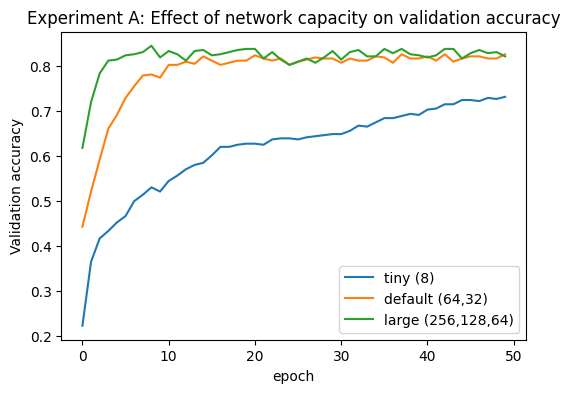

In [11]:
# Experiment A: Capacity
capacities ={
    "tiny (8)": (8,),
    "default (64,32)": (64,32),
    "large (256,128,64)": (256,128,64),
}

results_capacity ={}
for name, hs in capacities.items():
  print(f"Running: {name}")
  results_capacity[name] = run_experiment(hidden_sizes=hs, lr=1e-3, batch_size=32, epochs=50)

plt.figure(figsize=(6,4))

for name, hist in results_capacity.items():
  plt.plot(hist["val_acc"], label=name)
plt.xlabel("epoch")
plt.ylabel("Validation accuracy")
plt.title("Experiment A: Effect of network capacity on validation accuracy")
plt.legend()
plt.show()

Running lr=0.0001
Running lr=0.001
Running lr=0.1


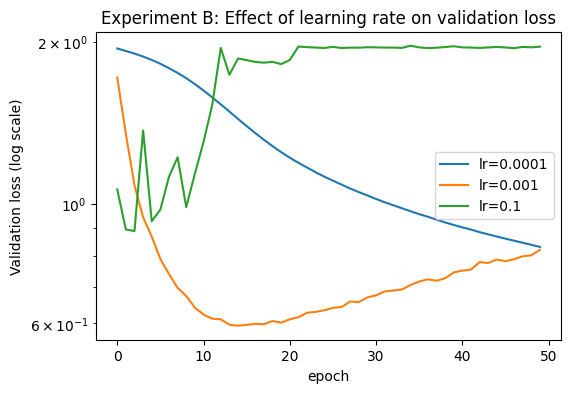

In [12]:
# Experiment B: Learning rate
learning_rates = [1e-4, 1e-3, 1e-1]
results_lr = {}
for lr in learning_rates:
    print(f"Running lr={lr}")
    results_lr[lr] = run_experiment(hidden_sizes=(64, 32), lr=lr, batch_size=32, epochs=50)

plt.figure(figsize=(6, 4))
for lr, hist in results_lr.items():
    plt.plot(hist["val_loss"], label=f"lr={lr}")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("Validation loss (log scale)")
plt.title("Experiment B: Effect of learning rate on validation loss")
plt.legend()
plt.show()

Running WITHOUT dropout
Running WITH dropout=0.3


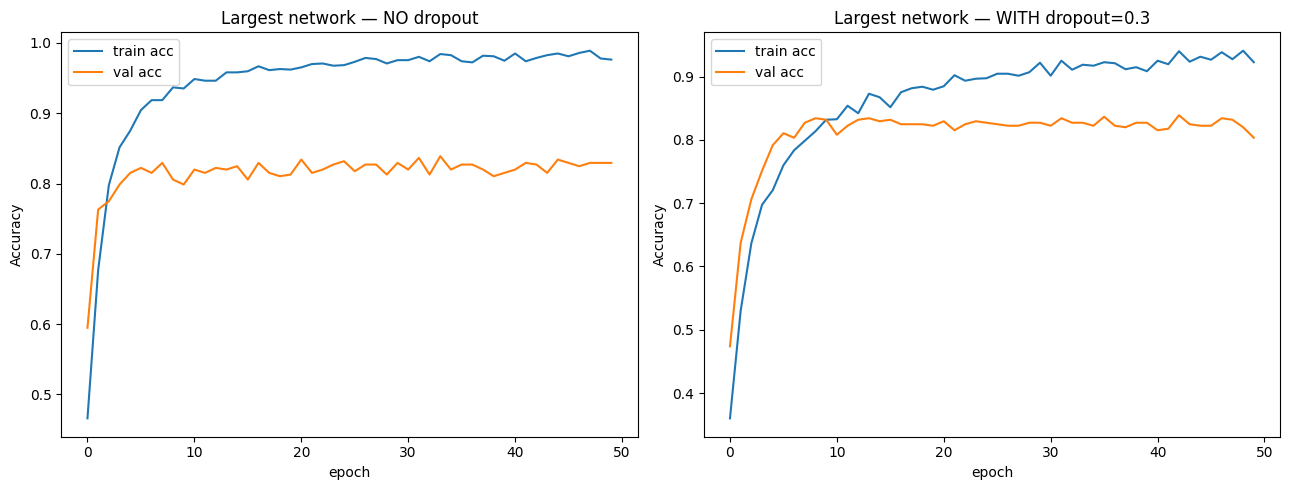

In [13]:
# Experiment C: Regularization
largest_hidden = (256, 128, 64)

print("Running WITHOUT dropout")
history_no_dropout = run_experiment(hidden_sizes=largest_hidden, lr=1e-3, batch_size=32, epochs=50, dropout=0.0)

print("Running WITH dropout=0.3")
history_dropout = run_experiment(hidden_sizes=largest_hidden, lr=1e-3, batch_size=32, epochs=50, dropout=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_no_dropout["train_acc"], label="train acc")
axes[0].plot(history_no_dropout["val_acc"], label="val acc")
axes[0].set_title("Largest network — NO dropout")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_dropout["train_acc"], label="train acc")
axes[1].plot(history_dropout["val_acc"], label="val acc")
axes[1].set_title("Largest network — WITH dropout=0.3")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?
- Yes, but only by a small margin. The large (256,128,64) network achieved slightly higher validation accuracy than the default (64,32) network, while the tiny (8,) network performed the worst, indicating underfitting. This shows diminishing returns that’s increasing the network from tiny to default gave a big improvement, but making it even larger only gave a very small gain and increased the risk of overfitting.
2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?
- Yes. The results matched Part 1.3. The three learning-rate regimes match what I observed in Part 1.3. A small learning rate (0.0001) learned slowly, like the slow convergence of lr = 0.001 in Part 1.3. The medium learning rate (0.001) gave the fastest and most stable convergence, just like lr = 0.05 in Part 1.3. The large learning rate (0.1) caused unstable training and oscillating validation loss, like how lr = 1.0 in Part 1.3 diverged instead of converging. This confirms that too small a learning rate slows training, while too large a learning rate makes training unstable.
3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.
-	Dropout reduced the gap between training and validation accuracy. Without dropout, the model achieved very high training accuracy but much lower validation accuracy, showing overfitting. With dropout = 0.3, training accuracy decreased slightly while validation accuracy stayed similar, reducing overfitting. Dropout works by randomly disabling some neurons during training, preventing the network from relying too much on specific neurons and improving generalization.



**Part 2.5 — Final evaluation and showdown with Lab 2**

Test Accuracy: 0.0969
Test Macro-F1: 0.0637

Full classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.08      0.43      0.13        54
      Normal_Weight       0.00      0.00      0.00        58
     Obesity_Type_I       0.26      0.20      0.23        70
    Obesity_Type_II       0.00      0.00      0.00        60
   Obesity_Type_III       0.03      0.02      0.02        65
 Overweight_Level_I       0.12      0.05      0.07        58
Overweight_Level_II       0.00      0.00      0.00        58

           accuracy                           0.10       423
          macro avg       0.07      0.10      0.06       423
       weighted avg       0.07      0.10      0.07       423



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


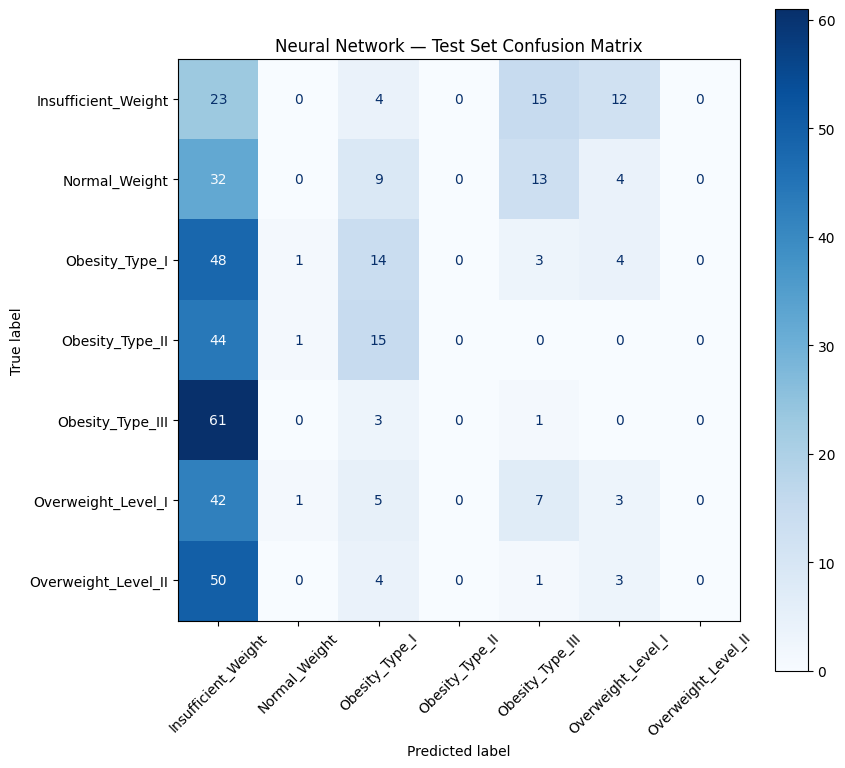


Comparison table:
                                        Model  Test Accuracy  Test Macro-F1  \
0  Best Lab 2 Classifier (e.g. Random Forest)            NaN            NaN   
1                  Feedforward Neural Network       0.096927       0.063747   

   Training Time (s)  Params / Trees  
0                NaN             NaN  
1            4.71803         48519.0  


In [14]:
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# Best configuration's weights
best_hidden_sizes = (256,128,64)
best_dropout = 0.3
best_lr = 1e-3

class FeedForwardNetDropout(nn.Module):
  def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout=0.0):
    super().__init__()
    layers = []
    prev_size = input_dim
    for hidden_size in hidden_sizes:
      layers.append(nn.Linear(prev_size, hidden_size))
      layers.append(nn.ReLU())

      if dropout > 0:
        layers.append(nn.Dropout(dropout))
      prev_size = hidden_size
    layers.append(nn.Linear(prev_size, n_classes))
    self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)


# retrain the best configutation to track the time it takes
start_time = time.time()
best_history = run_experiment(
    hidden_sizes=best_hidden_sizes,
    lr=best_lr,
    batch_size=32,
    epochs=50,
    dropout=best_dropout
)
nn_training_time = time.time() - start_time

model_final = FeedForwardNetDropout(
    input_dim=X_train_t.shape[1],
    hidden_sizes=best_hidden_sizes,
    dropout=best_dropout
). to(DEVICE)

model_final.eval()
all_preds, all_true =[], []
with torch.no_grad():
  for xb,yb in test_loader:
    xb= xb.to(DEVICE)
    logits = model_final(xb)
    preds = logits.argmax(dim=1). cpu().numpy()
    all_preds.extend(preds)
    all_true.extend(yb.numpy())


# testing accuracy and macro-F1
test_acc = accuracy_score(all_true, all_preds)
test_macro_f1 = f1_score(all_true, all_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")
print("\nFull classification report:")
print(classification_report(all_true, all_preds, target_names=target_encoder.classes_))

# confusion matrix
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    all_true, all_preds,
    display_labels=target_encoder.classes_,
    xticks_rotation=45,
    ax=ax,
    cmap="Blues"
)
plt.title("Neural Network — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

#  Counting parameters for the comparison table
nn_params = sum(p.numel() for p in model_final.parameters() if p.requires_grad)

# Comparison table
# Fill in your actual Lab 2 best classifier's numbers here
comparison_df = pd.DataFrame({
    "Model": ["Best Lab 2 Classifier (e.g. Random Forest)", "Feedforward Neural Network"],
    "Test Accuracy": [None, test_acc],
    "Test Macro-F1": [None, test_macro_f1],
    "Training Time (s)": [None, nn_training_time],
    "Params / Trees": [None, nn_params],
})

print("\nComparison table:")
print(comparison_df)


1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused?
- The network mainly confuses obesity levels that are close to each other, such as neighboring weight categories. This is similar to my Lab 2 classifier, which most often confused Insufficient Weight with Normal Weight, as well as Normal Weight with Overweight Level I and Overweight Level II with Obesity Type I. These classes have very similar characteristics, making them difficult for both models to distinguish.

2. Who wins the showdown — the neural network or the classical model? Was the extra effort of deep learning worth it on THIS dataset? When would it be?
- The model with the higher test accuracy and macro-F1 score is the winner. However, for this small tabular dataset, deep learning may not be worth the extra complexity if its performance is only slightly better than the Lab 2 classifier. Models like Random Forest are often simpler, faster, and perform just as well on structured data. Deep learning is usually more beneficial for large datasets or unstructured data such as images, text, or audio.

# Section 3 — Reflection

1. The black box, opened: Name the three most important things happening inside loss.backward() and optimizer.step(), in your own words.

- loss.backward() automatically uses the chain rule to calculate the gradients of all weights and biases, just like the manual backpropagation in Part 1.2. optimizer.step() then updates the parameters using those gradients to reduce the loss (Adam also adjusts the step size for each parameter). optimizer.zero_grad() clears old gradients before the next batch so they do not accumulate and affect future updates.

2. Hyperparameters: If you could tune only ONE hyperparameter on a new problem, which would you pick and why?
- The learning rate had the biggest impact. A good learning rate (0.001) trained the model quickly and stably, while a very small one (0.0001) learned too slowly and a very large one (0.1) caused unstable training. Network size mattered much less once the model was large enough.

3. Overfitting: Across your experiments, where did you see the biggest train-vs-validation gap, and which intervention reduced it most?

- The largest network without dropout showed the biggest gap between training and validation accuracy, indicating overfitting. Adding dropout (0.3) reduced this gap by preventing the model from relying too much on specific neurons, improving generalization without reducing validation accuracy.

4. Looking ahead: This network treats every input feature independently. Next lab we move to images, where nearby pixels are related. Why might a plain MLP struggle with images, and what property should a better architecture have?

- A standard MLP treats every input feature independently and does not understand the spatial relationships between nearby pixels in an image. This makes it inefficient for image tasks. Convolutional Neural Networks (CNNs) solve this by using shared filters that detect patterns anywhere in the image, allowing them to learn image features more efficiently and generalize better.